# Comprehensive Deep Learning Optimizers Benchmark
## Comparative Analysis: SGD, Momentum, AdaGrad, RMSProp, Adam & Nadam

---

### 👥 Seminar Presenters & Individual Responsibilities
* **Kunal (Presenter 1):** Foundational Pipeline, Standard SGD & SGD with Momentum
* **Rahul (Presenter 2):** Adaptive Learning Rates, AdaGrad & RMSProp
* **Pankaj (Presenter 3):** Combined Moments, Adam, Nadam & The Generalization Mystery
* **All Presenters:** Experimental Controls, Live Benchmark Walkthrough & Viva Defense

---

### 🏛️ System & Architectural Pipeline
Below is our universal end-to-end optimization pipeline showing how mini-batches flow through forward propagation, backpropagation, and optimizer internal memory buffers:

```
[Mini-Batch (Xt, Yt)] ──► [Forward Pass: MLP] ──► [Loss L(θt)] ──► [Backward Pass]
                                                                        │
                                                         Stochastic Gradient gt = ∇L
                                                                        ▼
                                                       ┌─────────────────────────────────┐
                                                       │ Universal Optimizer Pipeline    │
                                                       │                                 │
                                                       │ 1. Directional Buffer (mt)      │
                                                       │    (Momentum, Adam, Nadam)      │
                                                       │                                 │
                                                       │ 2. Adaptive Scale Buffer (vt)   │
                                                       │    (AdaGrad, RMSProp, Adam)     │
                                                       │                                 │
                                                       │ 3. Bias Correction (m̂t, v̂t)     │
                                                       │    (Adam, Nadam)                │
                                                       │                                 │
                                                       │ 4. Lookahead Step               │
                                                       │    (Nesterov, Nadam)            │
                                                       └────────────────┬────────────────┘
                                                                        ▼
                                                          Effective Update Δθt
                                                                        ▼
                                                         [θ_{t+1} = θt - Δθt]
```


## Step 1: Experimental Controls & 1,000-Sample Dataset
To ensure **100% scientific fairness**, every single optimizer will be benchmarked under strictly identical conditions:
1. **Dataset:** Exactly **1,000 training images** and **1,000 validation images** from Fashion-MNIST (100 images per clothing category).
2. **Fixed Random Seed:** `seed = 42` for identical data shuffling and batch ordering.
3. **Identical Initial Weights:** Cloned initial state $\theta_0$ via `copy.deepcopy`.


In [ ]:
# -------------------------------------------------------------
# STEP 1: Dependencies, Device Configuration & Dataset
# -------------------------------------------------------------
import os
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# 1. Ensure deterministic reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[OK] Computing device configured: {device}")

# 2. Fashion-MNIST Normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# 3. Load Fashion-MNIST and slice EXACTLY 1,000 samples
train_full = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_full = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 1,000 training samples (~100 images per clothing class)
train_dataset = Subset(train_full, list(range(1000)))
val_dataset = Subset(test_full, list(range(1000)))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print(f"[OK] Benchmark ready: {len(train_dataset)} training samples, {len(val_dataset)} validation samples.")


[OK] Computing device configured: cpu
[OK] Benchmark ready: 1000 training samples, 1000 validation samples.


## Step 2: 3-Layer MLP Model Architecture & Weight Freezing
* **Architecture:** $784 \to 128 \text{ (ReLU)} \to 64 \text{ (ReLU)} \to 10 \text{ (Logits)}$
* **Starting State:** We instantiate `reference_model` and freeze `initial_state_dict = copy.deepcopy(reference_model.state_dict())`.
* Every optimizer starts its gradient descent trajectory from this **exact same parameter coordinate $\theta_0$**.


In [2]:
# -------------------------------------------------------------
# STEP 2: Neural Network Architecture & Reference Weight Cloning
# -------------------------------------------------------------
class BenchmarkMLP(nn.Module):
    def __init__(self):
        super(BenchmarkMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

# Instantiate reference model and freeze initial weights theta_0
reference_model = BenchmarkMLP().to(device)
initial_state_dict = copy.deepcopy(reference_model.state_dict())
criterion = nn.CrossEntropyLoss()

# Validation evaluation helper
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += x.size(0)
    return total_loss / total, (correct / total) * 100.0

# Master results store for combined comparison dashboard
all_histories = {}
summary_table = []
print("[OK] BenchmarkMLP created and initial weights θ_0 cloned successfully.")


[OK] BenchmarkMLP created and initial weights θ_0 cloned successfully.


## Optimizer 1: Stochastic Gradient Descent (SGD)
* **Presenter:** Kunal
* **Mathematical Formula:**
  $$\theta_{t+1} = \theta_t - \eta \cdot g_t$$
* **Internal Memory:** 0 buffers (purely reactive)
* **Analogy:** A blind hiker taking quick, noisy steps in whichever direction slopes down right beneath their feet.
* **Limitation:** High variance in gradients causes violent oscillations across narrow ravines.


==================== Training SGD ====================
  Epoch [01/10] | Train Loss: 2.1270 | Val Loss: 1.8502 | Val Acc: 47.50%
  Epoch [02/10] | Train Loss: 1.5197 | Val Loss: 1.2593 | Val Acc: 60.20%
  Epoch [03/10] | Train Loss: 1.0533 | Val Loss: 0.9838 | Val Acc: 66.50%
  Epoch [04/10] | Train Loss: 0.8772 | Val Loss: 0.8460 | Val Acc: 69.80%
  Epoch [05/10] | Train Loss: 0.7575 | Val Loss: 0.7914 | Val Acc: 72.00%
  Epoch [06/10] | Train Loss: 0.6979 | Val Loss: 0.7760 | Val Acc: 72.80%
  Epoch [07/10] | Train Loss: 0.6518 | Val Loss: 0.7120 | Val Acc: 73.90%
  Epoch [08/10] | Train Loss: 0.5733 | Val Loss: 0.6972 | Val Acc: 73.30%
  Epoch [09/10] | Train Loss: 0.5468 | Val Loss: 0.6652 | Val Acc: 75.90%
  Epoch [10/10] | Train Loss: 0.5142 | Val Loss: 0.6549 | Val Acc: 75.10%
[+] Finished SGD in 9.42s


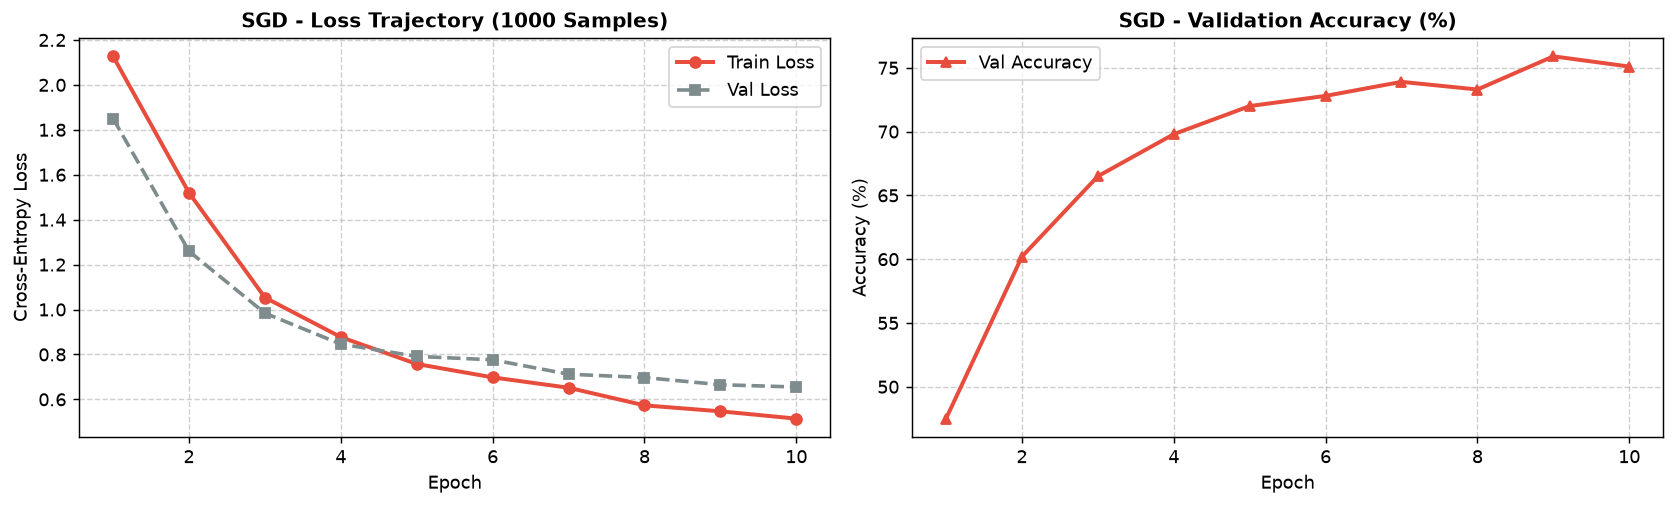

In [3]:
# =============================================================
# OPTIMIZER 1: Standard SGD (Presenter: Kunal)
# =============================================================
opt_name = "SGD"
color = "#e74c3c"  # Red
epochs = 10

# Load exact cloned starting weights
model_sgd = BenchmarkMLP().to(device)
model_sgd.load_state_dict(copy.deepcopy(initial_state_dict))
optimizer = optim.SGD(model_sgd.parameters(), lr=0.05)

hist_sgd = {"train_loss": [], "val_loss": [], "val_acc": []}
start_time = time.time()

print(f"==================== Training {opt_name} ====================")
for epoch in range(1, epochs + 1):
    model_sgd.train()
    running_loss, total_samples = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model_sgd(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        total_samples += x.size(0)

    train_l = running_loss / total_samples
    val_l, val_a = evaluate(model_sgd, val_loader)
    hist_sgd["train_loss"].append(train_l)
    hist_sgd["val_loss"].append(val_l)
    hist_sgd["val_acc"].append(val_a)
    print(f"  Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {train_l:.4f} | Val Loss: {val_l:.4f} | Val Acc: {val_a:.2f}%")

duration_sgd = time.time() - start_time
print(f"[+] Finished {opt_name} in {duration_sgd:.2f}s")
all_histories[opt_name] = hist_sgd
summary_table.append({
    "Optimizer": opt_name, "Final Train Loss": round(hist_sgd["train_loss"][-1], 4),
    "Final Val Loss": round(hist_sgd["val_loss"][-1], 4), "Final Val Acc (%)": round(hist_sgd["val_acc"][-1], 2),
    "Peak Val Acc (%)": round(max(hist_sgd["val_acc"]), 2), "Total Time (s)": round(duration_sgd, 2)
})

# Plot Individual 2-Panel Diagram for SGD
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_axis = list(range(1, epochs + 1))
ax1.plot(epochs_axis, hist_sgd["train_loss"], marker='o', color=color, linewidth=2.2, label='Train Loss')
ax1.plot(epochs_axis, hist_sgd["val_loss"], marker='s', color='#7f8c8d', linestyle='--', linewidth=2, label='Val Loss')
ax1.set_title(f"{opt_name} - Loss Trajectory (1000 Samples)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss"); ax1.legend(); ax1.grid(True, linestyle="--", alpha=0.6)

ax2.plot(epochs_axis, hist_sgd["val_acc"], marker='^', color=color, linewidth=2.2, label='Val Accuracy')
ax2.set_title(f"{opt_name} - Validation Accuracy (%)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.legend(); ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("./plots/01_sgd_benchmark.png", dpi=200, bbox_inches='tight')
plt.show()


## Optimizer 2: SGD with Momentum
* **Presenter:** Kunal
* **Mathematical Formula:**
  $$v_t = \beta \cdot v_{t-1} + g_t$$
  $$\theta_{t+1} = \theta_t - \eta \cdot v_t$$
* **Internal Memory:** 1 buffer ($v_t$, directional velocity vector)
* **Analogy:** A heavy bowling ball rolling down a valley; builds inertia in consistent directions and dampens perpendicular oscillations.
* **Advantage:** Accelerates through shallow ravines and cuts through noise.


==================== Training SGD + Momentum ====================
  Epoch [01/10] | Train Loss: 2.0480 | Val Loss: 1.4596 | Val Acc: 51.80%
  Epoch [02/10] | Train Loss: 1.0337 | Val Loss: 0.8941 | Val Acc: 66.10%
  Epoch [03/10] | Train Loss: 0.7479 | Val Loss: 0.7581 | Val Acc: 70.90%
  Epoch [04/10] | Train Loss: 0.6035 | Val Loss: 0.7344 | Val Acc: 69.30%
  Epoch [05/10] | Train Loss: 0.5037 | Val Loss: 0.6703 | Val Acc: 74.80%
  Epoch [06/10] | Train Loss: 0.4359 | Val Loss: 0.6307 | Val Acc: 76.00%
  Epoch [07/10] | Train Loss: 0.3807 | Val Loss: 0.6663 | Val Acc: 77.90%
  Epoch [08/10] | Train Loss: 0.3794 | Val Loss: 0.6192 | Val Acc: 77.80%
  Epoch [09/10] | Train Loss: 0.3510 | Val Loss: 0.6148 | Val Acc: 79.60%
  Epoch [10/10] | Train Loss: 0.3097 | Val Loss: 0.6583 | Val Acc: 78.10%
[+] Finished SGD + Momentum in 9.38s


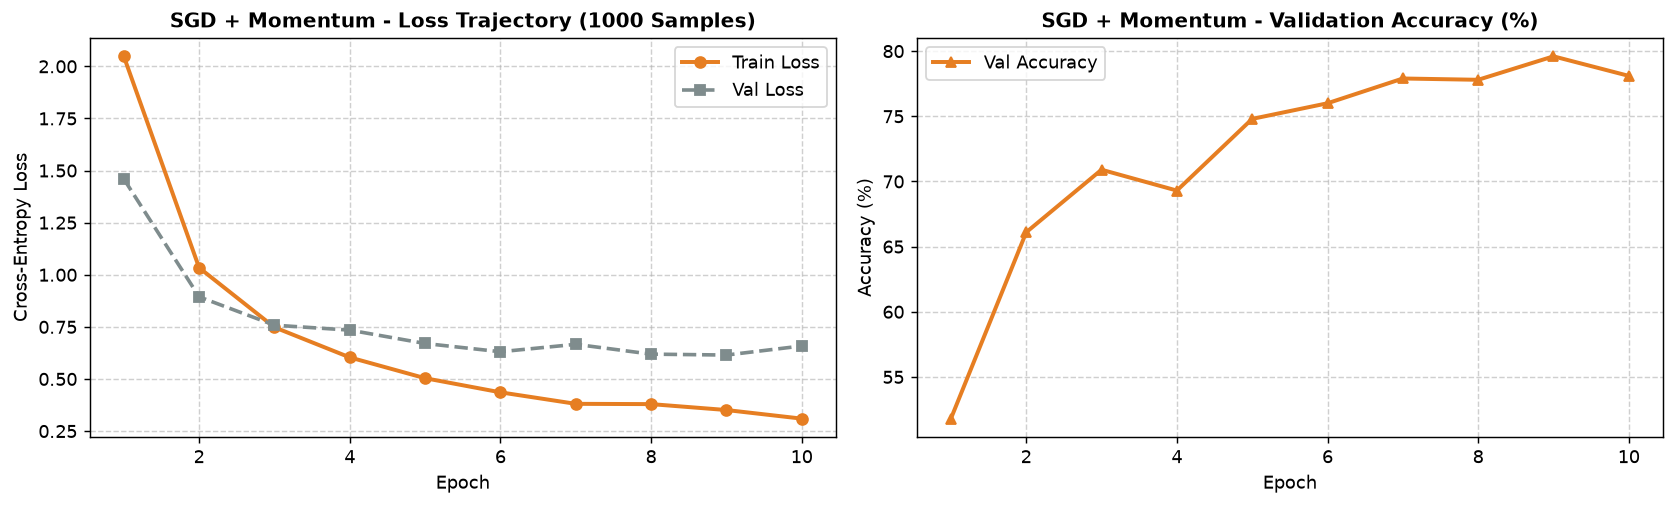

In [4]:
# =============================================================
# OPTIMIZER 2: SGD with Momentum (Presenter: Kunal)
# =============================================================
opt_name = "SGD + Momentum"
color = "#e67e22"  # Orange
epochs = 10

# Load exact cloned starting weights
model_mom = BenchmarkMLP().to(device)
model_mom.load_state_dict(copy.deepcopy(initial_state_dict))
optimizer = optim.SGD(model_mom.parameters(), lr=0.02, momentum=0.9)

hist_mom = {"train_loss": [], "val_loss": [], "val_acc": []}
start_time = time.time()

print(f"==================== Training {opt_name} ====================")
for epoch in range(1, epochs + 1):
    model_mom.train()
    running_loss, total_samples = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model_mom(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        total_samples += x.size(0)

    train_l = running_loss / total_samples
    val_l, val_a = evaluate(model_mom, val_loader)
    hist_mom["train_loss"].append(train_l)
    hist_mom["val_loss"].append(val_l)
    hist_mom["val_acc"].append(val_a)
    print(f"  Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {train_l:.4f} | Val Loss: {val_l:.4f} | Val Acc: {val_a:.2f}%")

duration_mom = time.time() - start_time
print(f"[+] Finished {opt_name} in {duration_mom:.2f}s")
all_histories[opt_name] = hist_mom
summary_table.append({
    "Optimizer": opt_name, "Final Train Loss": round(hist_mom["train_loss"][-1], 4),
    "Final Val Loss": round(hist_mom["val_loss"][-1], 4), "Final Val Acc (%)": round(hist_mom["val_acc"][-1], 2),
    "Peak Val Acc (%)": round(max(hist_mom["val_acc"]), 2), "Total Time (s)": round(duration_mom, 2)
})

# Plot Individual 2-Panel Diagram for SGD + Momentum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_axis = list(range(1, epochs + 1))
ax1.plot(epochs_axis, hist_mom["train_loss"], marker='o', color=color, linewidth=2.2, label='Train Loss')
ax1.plot(epochs_axis, hist_mom["val_loss"], marker='s', color='#7f8c8d', linestyle='--', linewidth=2, label='Val Loss')
ax1.set_title(f"{opt_name} - Loss Trajectory (1000 Samples)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss"); ax1.legend(); ax1.grid(True, linestyle="--", alpha=0.6)

ax2.plot(epochs_axis, hist_mom["val_acc"], marker='^', color=color, linewidth=2.2, label='Val Accuracy')
ax2.set_title(f"{opt_name} - Validation Accuracy (%)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.legend(); ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("./plots/02_momentum_benchmark.png", dpi=200, bbox_inches='tight')
plt.show()


## Optimizer 3: AdaGrad (Adaptive Gradient)
* **Presenter:** Rahul
* **Mathematical Formula:**
  $$G_t = G_{t-1} + g_t^2$$
  $$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t + \epsilon}} \odot g_t$$
* **Internal Memory:** 1 buffer ($G_t$, cumulative sum of squared gradients)
* **Analogy:** Elephant memory; remembers the entire history of gradients since step 0.
* **Limitation:** Because $g_t^2 \ge 0$, $G_t$ grows monotonically, causing effective learning rate $\frac{\eta}{\sqrt{G_t+\epsilon}} \to 0$ (premature learning stoppage).


==================== Training AdaGrad ====================
  Epoch [01/10] | Train Loss: 1.3626 | Val Loss: 0.8372 | Val Acc: 71.80%
  Epoch [02/10] | Train Loss: 0.7087 | Val Loss: 0.7604 | Val Acc: 70.10%
  Epoch [03/10] | Train Loss: 0.5772 | Val Loss: 0.6553 | Val Acc: 76.90%
  Epoch [04/10] | Train Loss: 0.4999 | Val Loss: 0.5969 | Val Acc: 77.20%
  Epoch [05/10] | Train Loss: 0.4201 | Val Loss: 0.7362 | Val Acc: 70.10%
  Epoch [06/10] | Train Loss: 0.3936 | Val Loss: 0.5983 | Val Acc: 78.20%
  Epoch [07/10] | Train Loss: 0.3503 | Val Loss: 0.6450 | Val Acc: 75.00%
  Epoch [08/10] | Train Loss: 0.3181 | Val Loss: 0.6002 | Val Acc: 79.30%
  Epoch [09/10] | Train Loss: 0.3031 | Val Loss: 0.5710 | Val Acc: 80.00%
  Epoch [10/10] | Train Loss: 0.2629 | Val Loss: 0.5982 | Val Acc: 79.80%
[+] Finished AdaGrad in 10.17s


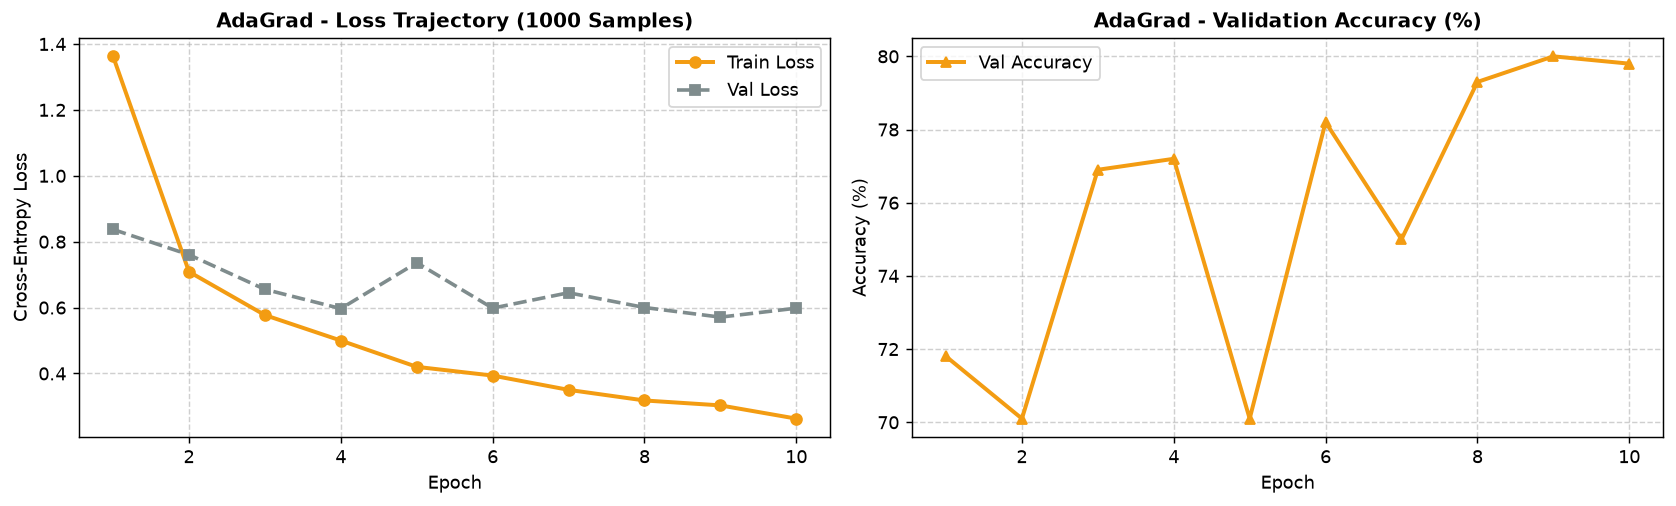

In [5]:
# =============================================================
# OPTIMIZER 3: AdaGrad (Presenter: Rahul)
# =============================================================
opt_name = "AdaGrad"
color = "#f39c12"  # Amber
epochs = 10

# Load exact cloned starting weights
model_ada = BenchmarkMLP().to(device)
model_ada.load_state_dict(copy.deepcopy(initial_state_dict))
optimizer = optim.Adagrad(model_ada.parameters(), lr=0.01)

hist_ada = {"train_loss": [], "val_loss": [], "val_acc": []}
start_time = time.time()

print(f"==================== Training {opt_name} ====================")
for epoch in range(1, epochs + 1):
    model_ada.train()
    running_loss, total_samples = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model_ada(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        total_samples += x.size(0)

    train_l = running_loss / total_samples
    val_l, val_a = evaluate(model_ada, val_loader)
    hist_ada["train_loss"].append(train_l)
    hist_ada["val_loss"].append(val_l)
    hist_ada["val_acc"].append(val_a)
    print(f"  Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {train_l:.4f} | Val Loss: {val_l:.4f} | Val Acc: {val_a:.2f}%")

duration_ada = time.time() - start_time
print(f"[+] Finished {opt_name} in {duration_ada:.2f}s")
all_histories[opt_name] = hist_ada
summary_table.append({
    "Optimizer": opt_name, "Final Train Loss": round(hist_ada["train_loss"][-1], 4),
    "Final Val Loss": round(hist_ada["val_loss"][-1], 4), "Final Val Acc (%)": round(hist_ada["val_acc"][-1], 2),
    "Peak Val Acc (%)": round(max(hist_ada["val_acc"]), 2), "Total Time (s)": round(duration_ada, 2)
})

# Plot Individual 2-Panel Diagram for AdaGrad
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_axis = list(range(1, epochs + 1))
ax1.plot(epochs_axis, hist_ada["train_loss"], marker='o', color=color, linewidth=2.2, label='Train Loss')
ax1.plot(epochs_axis, hist_ada["val_loss"], marker='s', color='#7f8c8d', linestyle='--', linewidth=2, label='Val Loss')
ax1.set_title(f"{opt_name} - Loss Trajectory (1000 Samples)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss"); ax1.legend(); ax1.grid(True, linestyle="--", alpha=0.6)

ax2.plot(epochs_axis, hist_ada["val_acc"], marker='^', color=color, linewidth=2.2, label='Val Accuracy')
ax2.set_title(f"{opt_name} - Validation Accuracy (%)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.legend(); ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("./plots/03_adagrad_benchmark.png", dpi=200, bbox_inches='tight')
plt.show()


## Optimizer 4: RMSProp (Root Mean Square Propagation)
* **Presenter:** Rahul
* **Mathematical Formula:**
  $$v_t = \beta \cdot v_{t-1} + (1 - \beta) \cdot g_t^2$$
  $$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{v_t + \epsilon}} \odot g_t$$
* **Internal Memory:** 1 buffer ($v_t$, exponentially decaying moving average of squared gradients)
* **Analogy:** Human memory with a short horizon; remembers recent slopes and discards ancient history.
* **Fix for AdaGrad:** Replaces the unconstrained sum with an Exponential Moving Average (EMA, $\beta=0.9$), preventing the learning rate from vanishing.


==================== Training RMSProp ====================
  Epoch [01/10] | Train Loss: 1.3976 | Val Loss: 0.9665 | Val Acc: 66.40%
  Epoch [02/10] | Train Loss: 0.7924 | Val Loss: 0.7670 | Val Acc: 71.40%
  Epoch [03/10] | Train Loss: 0.6477 | Val Loss: 0.7096 | Val Acc: 74.20%
  Epoch [04/10] | Train Loss: 0.5717 | Val Loss: 0.6536 | Val Acc: 77.70%
  Epoch [05/10] | Train Loss: 0.4917 | Val Loss: 0.6831 | Val Acc: 76.40%
  Epoch [06/10] | Train Loss: 0.4546 | Val Loss: 0.7152 | Val Acc: 72.90%
  Epoch [07/10] | Train Loss: 0.4369 | Val Loss: 0.6198 | Val Acc: 78.10%
  Epoch [08/10] | Train Loss: 0.3935 | Val Loss: 0.5757 | Val Acc: 79.20%
  Epoch [09/10] | Train Loss: 0.3556 | Val Loss: 0.5576 | Val Acc: 79.90%
  Epoch [10/10] | Train Loss: 0.3147 | Val Loss: 0.7311 | Val Acc: 74.90%
[+] Finished RMSProp in 9.52s


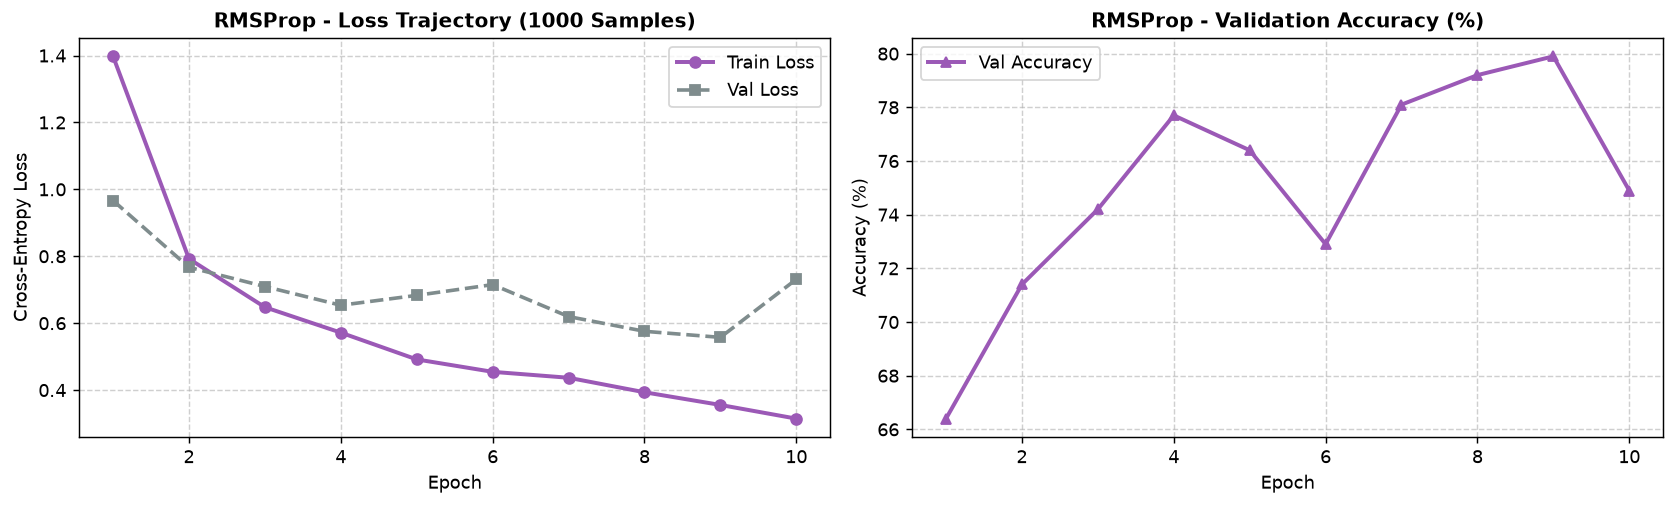

In [6]:
# =============================================================
# OPTIMIZER 4: RMSProp (Presenter: Rahul)
# =============================================================
opt_name = "RMSProp"
color = "#9b59b6"  # Purple
epochs = 10

# Load exact cloned starting weights
model_rms = BenchmarkMLP().to(device)
model_rms.load_state_dict(copy.deepcopy(initial_state_dict))
optimizer = optim.RMSprop(model_rms.parameters(), lr=0.001, alpha=0.9)

hist_rms = {"train_loss": [], "val_loss": [], "val_acc": []}
start_time = time.time()

print(f"==================== Training {opt_name} ====================")
for epoch in range(1, epochs + 1):
    model_rms.train()
    running_loss, total_samples = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model_rms(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        total_samples += x.size(0)

    train_l = running_loss / total_samples
    val_l, val_a = evaluate(model_rms, val_loader)
    hist_rms["train_loss"].append(train_l)
    hist_rms["val_loss"].append(val_l)
    hist_rms["val_acc"].append(val_a)
    print(f"  Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {train_l:.4f} | Val Loss: {val_l:.4f} | Val Acc: {val_a:.2f}%")

duration_rms = time.time() - start_time
print(f"[+] Finished {opt_name} in {duration_rms:.2f}s")
all_histories[opt_name] = hist_rms
summary_table.append({
    "Optimizer": opt_name, "Final Train Loss": round(hist_rms["train_loss"][-1], 4),
    "Final Val Loss": round(hist_rms["val_loss"][-1], 4), "Final Val Acc (%)": round(hist_rms["val_acc"][-1], 2),
    "Peak Val Acc (%)": round(max(hist_rms["val_acc"]), 2), "Total Time (s)": round(duration_rms, 2)
})

# Plot Individual 2-Panel Diagram for RMSProp
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_axis = list(range(1, epochs + 1))
ax1.plot(epochs_axis, hist_rms["train_loss"], marker='o', color=color, linewidth=2.2, label='Train Loss')
ax1.plot(epochs_axis, hist_rms["val_loss"], marker='s', color='#7f8c8d', linestyle='--', linewidth=2, label='Val Loss')
ax1.set_title(f"{opt_name} - Loss Trajectory (1000 Samples)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss"); ax1.legend(); ax1.grid(True, linestyle="--", alpha=0.6)

ax2.plot(epochs_axis, hist_rms["val_acc"], marker='^', color=color, linewidth=2.2, label='Val Accuracy')
ax2.set_title(f"{opt_name} - Validation Accuracy (%)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.legend(); ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("./plots/04_rmsprop_benchmark.png", dpi=200, bbox_inches='tight')
plt.show()


## Optimizer 5: Adam (Adaptive Moment Estimation)
* **Presenter:** Pankaj
* **Mathematical Formulation:**
  $$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \quad \text{(1st Moment: Momentum)}$$
  $$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \quad \text{(2nd Moment: RMSProp)}$$
  $$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} \quad \text{(Bias Correction)}$$
  $$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \odot \hat{m}_t$$
* **Internal Memory:** 2 buffers ($m_t$ and $v_t$)
* **Why Bias Correction?** Because $m_0=0$ and $v_0=0$, early updates are biased towards 0. Dividing by $(1-\beta^t)$ normalizes initial steps.


==================== Training Adam ====================
  Epoch [01/10] | Train Loss: 1.6581 | Val Loss: 1.0395 | Val Acc: 64.40%
  Epoch [02/10] | Train Loss: 0.8225 | Val Loss: 0.7619 | Val Acc: 69.90%
  Epoch [03/10] | Train Loss: 0.6233 | Val Loss: 0.6800 | Val Acc: 75.60%
  Epoch [04/10] | Train Loss: 0.5245 | Val Loss: 0.6428 | Val Acc: 77.40%
  Epoch [05/10] | Train Loss: 0.4627 | Val Loss: 0.6407 | Val Acc: 77.50%
  Epoch [06/10] | Train Loss: 0.4340 | Val Loss: 0.6761 | Val Acc: 76.30%
  Epoch [07/10] | Train Loss: 0.3898 | Val Loss: 0.5742 | Val Acc: 80.10%
  Epoch [08/10] | Train Loss: 0.3292 | Val Loss: 0.6173 | Val Acc: 77.50%
  Epoch [09/10] | Train Loss: 0.3129 | Val Loss: 0.5680 | Val Acc: 79.20%
  Epoch [10/10] | Train Loss: 0.2719 | Val Loss: 0.5817 | Val Acc: 79.40%
[+] Finished Adam in 9.59s


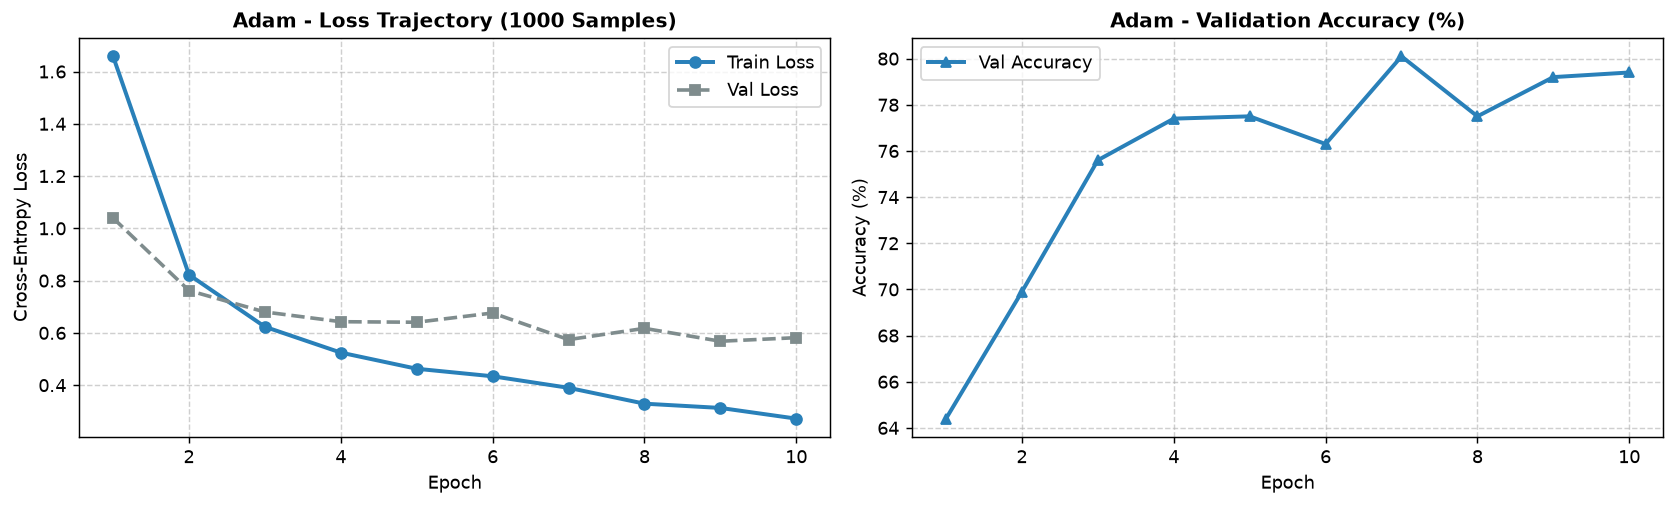

In [7]:
# =============================================================
# OPTIMIZER 5: Adam (Presenter: Pankaj)
# =============================================================
opt_name = "Adam"
color = "#2980b9"  # Blue
epochs = 10

# Load exact cloned starting weights
model_adam = BenchmarkMLP().to(device)
model_adam.load_state_dict(copy.deepcopy(initial_state_dict))
optimizer = optim.Adam(model_adam.parameters(), lr=0.001, betas=(0.9, 0.999))

hist_adam = {"train_loss": [], "val_loss": [], "val_acc": []}
start_time = time.time()

print(f"==================== Training {opt_name} ====================")
for epoch in range(1, epochs + 1):
    model_adam.train()
    running_loss, total_samples = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model_adam(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        total_samples += x.size(0)

    train_l = running_loss / total_samples
    val_l, val_a = evaluate(model_adam, val_loader)
    hist_adam["train_loss"].append(train_l)
    hist_adam["val_loss"].append(val_l)
    hist_adam["val_acc"].append(val_a)
    print(f"  Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {train_l:.4f} | Val Loss: {val_l:.4f} | Val Acc: {val_a:.2f}%")

duration_adam = time.time() - start_time
print(f"[+] Finished {opt_name} in {duration_adam:.2f}s")
all_histories[opt_name] = hist_adam
summary_table.append({
    "Optimizer": opt_name, "Final Train Loss": round(hist_adam["train_loss"][-1], 4),
    "Final Val Loss": round(hist_adam["val_loss"][-1], 4), "Final Val Acc (%)": round(hist_adam["val_acc"][-1], 2),
    "Peak Val Acc (%)": round(max(hist_adam["val_acc"]), 2), "Total Time (s)": round(duration_adam, 2)
})

# Plot Individual 2-Panel Diagram for Adam
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_axis = list(range(1, epochs + 1))
ax1.plot(epochs_axis, hist_adam["train_loss"], marker='o', color=color, linewidth=2.2, label='Train Loss')
ax1.plot(epochs_axis, hist_adam["val_loss"], marker='s', color='#7f8c8d', linestyle='--', linewidth=2, label='Val Loss')
ax1.set_title(f"{opt_name} - Loss Trajectory (1000 Samples)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss"); ax1.legend(); ax1.grid(True, linestyle="--", alpha=0.6)

ax2.plot(epochs_axis, hist_adam["val_acc"], marker='^', color=color, linewidth=2.2, label='Val Accuracy')
ax2.set_title(f"{opt_name} - Validation Accuracy (%)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.legend(); ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("./plots/05_adam_benchmark.png", dpi=200, bbox_inches='tight')
plt.show()


## Optimizer 6: Nadam (Nesterov-Accelerated Adam)
* **Presenter:** Pankaj
* **Mathematical Formulation:**
  $$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \left( \beta_1 \hat{m}_t + \frac{(1 - \beta_1) g_t}{1 - \beta_1^t} \right)$$
* **Internal Memory:** 2 buffers ($m_t$ and $v_t$)
* **Key Innovation:** Incorporates **Nesterov Lookahead** directly into the first-moment calculation, evaluating gradients one step ahead before making the jump!


==================== Training Nadam ====================
  Epoch [01/10] | Train Loss: 1.6551 | Val Loss: 1.0236 | Val Acc: 66.00%
  Epoch [02/10] | Train Loss: 0.8061 | Val Loss: 0.7214 | Val Acc: 73.60%
  Epoch [03/10] | Train Loss: 0.6251 | Val Loss: 0.6498 | Val Acc: 77.40%
  Epoch [04/10] | Train Loss: 0.5297 | Val Loss: 0.6749 | Val Acc: 74.20%
  Epoch [05/10] | Train Loss: 0.4536 | Val Loss: 0.7477 | Val Acc: 73.80%
  Epoch [06/10] | Train Loss: 0.4131 | Val Loss: 0.5939 | Val Acc: 78.50%
  Epoch [07/10] | Train Loss: 0.3637 | Val Loss: 0.6309 | Val Acc: 77.60%
  Epoch [08/10] | Train Loss: 0.3210 | Val Loss: 0.5706 | Val Acc: 80.30%
  Epoch [09/10] | Train Loss: 0.2972 | Val Loss: 0.6676 | Val Acc: 75.00%
  Epoch [10/10] | Train Loss: 0.2828 | Val Loss: 0.6255 | Val Acc: 77.60%
[+] Finished Nadam in 9.46s


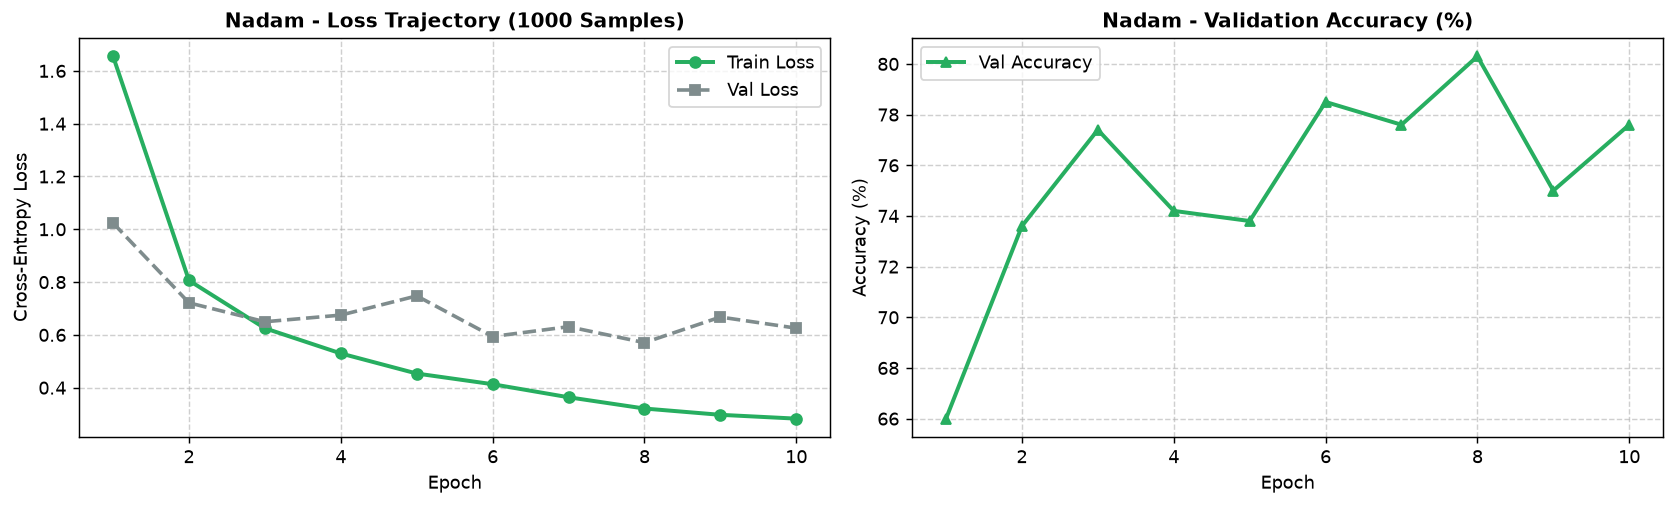

In [8]:
# =============================================================
# OPTIMIZER 6: Nadam (Presenter: Pankaj)
# =============================================================
opt_name = "Nadam"
color = "#27ae60"  # Green
epochs = 10

# Load exact cloned starting weights
model_nadam = BenchmarkMLP().to(device)
model_nadam.load_state_dict(copy.deepcopy(initial_state_dict))
optimizer = optim.NAdam(model_nadam.parameters(), lr=0.001, betas=(0.9, 0.999))

hist_nadam = {"train_loss": [], "val_loss": [], "val_acc": []}
start_time = time.time()

print(f"==================== Training {opt_name} ====================")
for epoch in range(1, epochs + 1):
    model_nadam.train()
    running_loss, total_samples = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model_nadam(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        total_samples += x.size(0)

    train_l = running_loss / total_samples
    val_l, val_a = evaluate(model_nadam, val_loader)
    hist_nadam["train_loss"].append(train_l)
    hist_nadam["val_loss"].append(val_l)
    hist_nadam["val_acc"].append(val_a)
    print(f"  Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {train_l:.4f} | Val Loss: {val_l:.4f} | Val Acc: {val_a:.2f}%")

duration_nadam = time.time() - start_time
print(f"[+] Finished {opt_name} in {duration_nadam:.2f}s")
all_histories[opt_name] = hist_nadam
summary_table.append({
    "Optimizer": opt_name, "Final Train Loss": round(hist_nadam["train_loss"][-1], 4),
    "Final Val Loss": round(hist_nadam["val_loss"][-1], 4), "Final Val Acc (%)": round(hist_nadam["val_acc"][-1], 2),
    "Peak Val Acc (%)": round(max(hist_nadam["val_acc"]), 2), "Total Time (s)": round(duration_nadam, 2)
})

# Plot Individual 2-Panel Diagram for Nadam
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_axis = list(range(1, epochs + 1))
ax1.plot(epochs_axis, hist_nadam["train_loss"], marker='o', color=color, linewidth=2.2, label='Train Loss')
ax1.plot(epochs_axis, hist_nadam["val_loss"], marker='s', color='#7f8c8d', linestyle='--', linewidth=2, label='Val Loss')
ax1.set_title(f"{opt_name} - Loss Trajectory (1000 Samples)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss"); ax1.legend(); ax1.grid(True, linestyle="--", alpha=0.6)

ax2.plot(epochs_axis, hist_nadam["val_acc"], marker='^', color=color, linewidth=2.2, label='Val Accuracy')
ax2.set_title(f"{opt_name} - Validation Accuracy (%)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.legend(); ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("./plots/06_nadam_benchmark.png", dpi=200, bbox_inches='tight')
plt.show()


## Master Combined Comparison Dashboard (All 6 Optimizers Overlaid)
* **Presenter:** All Members (Kunal, Rahul, Pankaj)
* **Objective:** Directly compare convergence speed, validation loss stability, peak accuracy, and execution runtime side-by-side on the exact same 1,000 samples.



FINAL BENCHMARK COMPARISON TABLE (1,000 SAMPLES)
     Optimizer  Final Train Loss  Final Val Loss  Final Val Acc (%)  Peak Val Acc (%)  Total Time (s)
           SGD            0.5142          0.6549               75.1              75.9            9.42
SGD + Momentum            0.3097          0.6583               78.1              79.6            9.38
       AdaGrad            0.2629          0.5982               79.8              80.0           10.17
       RMSProp            0.3147          0.7311               74.9              79.9            9.52
          Adam            0.2719          0.5817               79.4              80.1            9.59
         Nadam            0.2828          0.6255               77.6              80.3            9.46


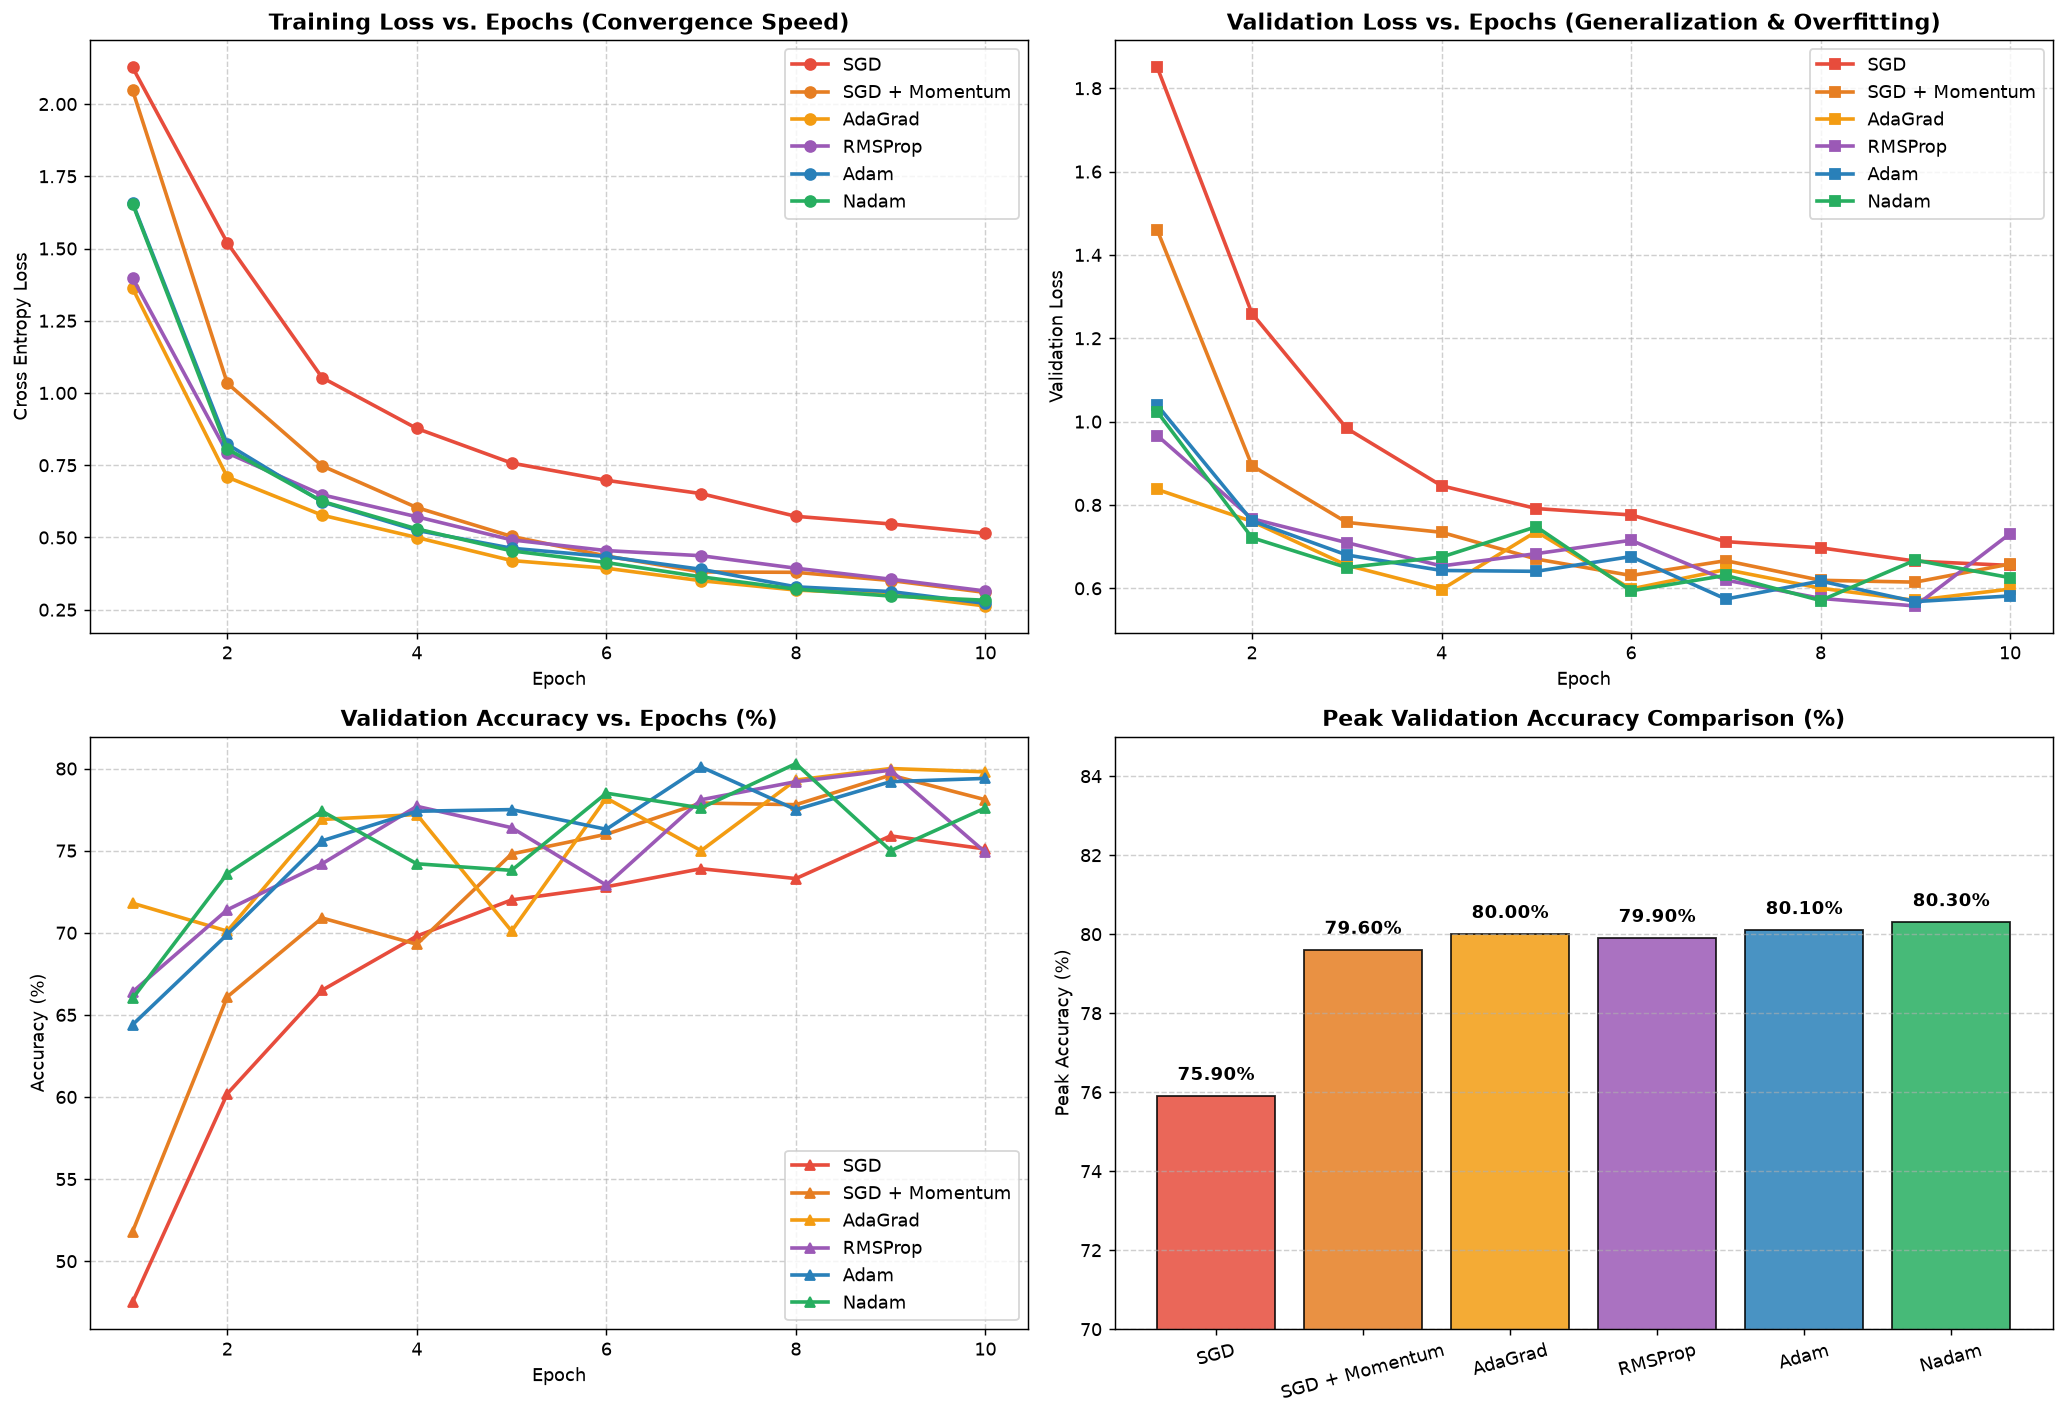

In [9]:
# -------------------------------------------------------------
# STEP 3: Combined 4-Panel Comparative Dashboard
# -------------------------------------------------------------
color_map = {
    "SGD": "#e74c3c", "SGD + Momentum": "#e67e22",
    "AdaGrad": "#f39c12", "RMSProp": "#9b59b6",
    "Adam": "#2980b9", "Nadam": "#27ae60"
}

fig, axs = plt.subplots(2, 2, figsize=(16, 11))
epochs_axis = list(range(1, 11))

# 1. Training Loss Over Epochs
for name, hist in all_histories.items():
    axs[0, 0].plot(epochs_axis, hist["train_loss"], label=name, color=color_map[name], marker='o', linewidth=2)
axs[0, 0].set_title("Training Loss vs. Epochs (Convergence Speed)", fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel("Epoch"); axs[0, 0].set_ylabel("Cross Entropy Loss"); axs[0, 0].legend(); axs[0, 0].grid(True, linestyle="--", alpha=0.6)

# 2. Validation Loss Over Epochs
for name, hist in all_histories.items():
    axs[0, 1].plot(epochs_axis, hist["val_loss"], label=name, color=color_map[name], marker='s', linewidth=2)
axs[0, 1].set_title("Validation Loss vs. Epochs (Generalization & Overfitting)", fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel("Epoch"); axs[0, 1].set_ylabel("Validation Loss"); axs[0, 1].legend(); axs[0, 1].grid(True, linestyle="--", alpha=0.6)

# 3. Validation Accuracy Over Epochs
for name, hist in all_histories.items():
    axs[1, 0].plot(epochs_axis, hist["val_acc"], label=name, color=color_map[name], marker='^', linewidth=2)
axs[1, 0].set_title("Validation Accuracy vs. Epochs (%)", fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel("Epoch"); axs[1, 0].set_ylabel("Accuracy (%)"); axs[1, 0].legend(); axs[1, 0].grid(True, linestyle="--", alpha=0.6)

# 4. Peak Accuracy Bar Chart
df_comparison = pd.DataFrame(summary_table)
opts = df_comparison["Optimizer"].tolist()
peaks = df_comparison["Peak Val Acc (%)"].tolist()
bars = axs[1, 1].bar(opts, peaks, color=[color_map[o] for o in opts], alpha=0.85, edgecolor='black')
axs[1, 1].set_ylim(70, 85)
axs[1, 1].set_title("Peak Validation Accuracy Comparison (%)", fontsize=12, fontweight='bold')
axs[1, 1].set_ylabel("Peak Accuracy (%)")
for bar in bars:
    y = bar.get_height()
    axs[1, 1].text(bar.get_x() + bar.get_width()/2.0, y + 0.3, f"{y:.2f}%", ha='center', va='bottom', fontweight='bold')
axs[1, 1].tick_params(axis='x', rotation=15); axs[1, 1].grid(True, axis='y', linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("./plots/all_optimizers_comparison.png", dpi=250, bbox_inches='tight')
plt.show()

df_comparison.to_csv("./plots/benchmark_summary.csv", index=False)
print("\n" + "="*85)
print("FINAL BENCHMARK COMPARISON TABLE (1,000 SAMPLES)")
print("="*85)
print(df_comparison.to_string(index=False))


## Learning Rate Sensitivity Benchmark
* **Experimental Sweep:** Testing 4 optimizers across 4 orders of magnitude:
  $$\eta \in [10^{-1}, 10^{-2}, 10^{-3}, 10^{-4}]$$
* **Finding:** Shows which optimizers are fragile to tuning vs. which are forgiving and stable.


[+] Evaluating learning rate sensitivity across 4 decades...
  > SGD             @ lr=0.1     | 3-Epoch Val Acc = 58.80%
  > SGD             @ lr=0.01    | 3-Epoch Val Acc = 40.60%
  > SGD             @ lr=0.001   | 3-Epoch Val Acc = 12.20%
  > SGD             @ lr=0.0001  | 3-Epoch Val Acc = 7.00%
  > SGD + Momentum  @ lr=0.1     | 3-Epoch Val Acc = 70.90%
  > SGD + Momentum  @ lr=0.01    | 3-Epoch Val Acc = 69.40%
  > SGD + Momentum  @ lr=0.001   | 3-Epoch Val Acc = 37.90%
  > SGD + Momentum  @ lr=0.0001  | 3-Epoch Val Acc = 10.80%
  > AdaGrad         @ lr=0.1     | 3-Epoch Val Acc = 70.70%
  > AdaGrad         @ lr=0.01    | 3-Epoch Val Acc = 70.90%
  > AdaGrad         @ lr=0.001   | 3-Epoch Val Acc = 70.60%
  > AdaGrad         @ lr=0.0001  | 3-Epoch Val Acc = 37.50%
  > Adam            @ lr=0.1     | 3-Epoch Val Acc = 32.70%
  > Adam            @ lr=0.01    | 3-Epoch Val Acc = 74.60%
  > Adam            @ lr=0.001   | 3-Epoch Val Acc = 74.50%
  > Adam            @ lr=0.0001  | 3-Epo

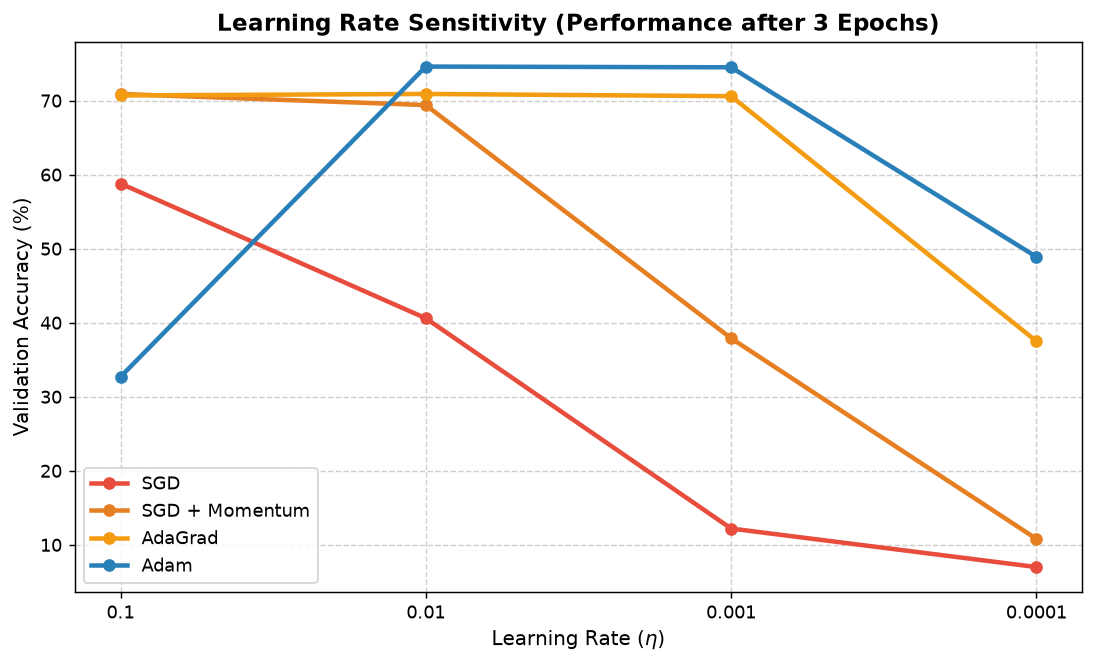

In [10]:
# -------------------------------------------------------------
# STEP 4: Learning Rate Sensitivity Sweep (3 Epochs Evaluation)
# -------------------------------------------------------------
lrs = [0.1, 0.01, 0.001, 0.0001]
test_opts = ["SGD", "SGD + Momentum", "AdaGrad", "Adam"]
sens_results = {opt: [] for opt in test_opts}

def get_sens_opt(opt_name, model_inst, lr):
    if opt_name == "SGD": return optim.SGD(model_inst.parameters(), lr=lr)
    elif opt_name == "SGD + Momentum": return optim.SGD(model_inst.parameters(), lr=lr, momentum=0.9)
    elif opt_name == "AdaGrad": return optim.Adagrad(model_inst.parameters(), lr=lr)
    elif opt_name == "Adam": return optim.Adam(model_inst.parameters(), lr=lr)

print("[+] Evaluating learning rate sensitivity across 4 decades...")
for opt in test_opts:
    for lr in lrs:
        set_seed(42)
        m = BenchmarkMLP().to(device)
        m.load_state_dict(copy.deepcopy(initial_state_dict))
        optimizer = get_sens_opt(opt, m, lr)
        m.train()
        for ep in range(3):
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                out = m(x)
                loss = criterion(out, y)
                loss.backward()
                optimizer.step()
        _, acc = evaluate(m, val_loader)
        sens_results[opt].append(acc)
        print(f"  > {opt:15s} @ lr={lr:<7} | 3-Epoch Val Acc = {acc:.2f}%")

# Plot Sensitivity Curve
plt.figure(figsize=(10, 5.5))
for opt in test_opts:
    plt.plot([str(lr) for lr in lrs], sens_results[opt], marker='o', linewidth=2.5, label=opt, color=color_map[opt])

plt.title("Learning Rate Sensitivity (Performance after 3 Epochs)", fontsize=13, fontweight='bold')
plt.xlabel(r"Learning Rate ($\eta$)", fontsize=11)
plt.ylabel("Validation Accuracy (%)", fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("./plots/learning_rate_sensitivity.png", dpi=200, bbox_inches='tight')
plt.show()


## The Generalization Mystery & Viva Defense Reference

### Flat vs. Sharp Minima
```
 Loss
  ▲
  │       Sharp Minimum (Adam)           Flat Minimum (SGD + Momentum)
  │       High Test Error Shift             Low Test Error Shift
  │
  │           \     /                              \             /
  │            \   /                                \___________/
  │             \_/
  │          Training: Low Loss               Training: Low Loss
  │          Testing:  HIGH ERROR             Testing:  LOW ERROR
  └───────────────────────────────────────────────────────────────────► Weights (θ)
```

---

### 10-Second Viva Cheat Sheet for Professor Questions:
1. **Q: Which optimizer for sparse text/word embeddings?**
   * **Answer:** **AdaGrad or Adam**, because dividing by cumulative squared gradients amplifies rare feature updates.
2. **Q: Which optimizer for noisy batches?**
   * **Answer:** **SGD + Momentum or Adam**, because the 1st-moment exponential moving average acts as a low-pass filter to cancel noise.
3. **Q: How do optimizers escape saddle points?**
   * **Answer:** **Momentum or Adam**, because inertia carries parameters across zero-gradient plateaus.
4. **Q: Why divide by $(1-\beta^t)$ in Adam?**
   * **Answer:** Because buffers start at zero; dividing by $(1-\beta^t)$ removes the cold-start initialization bias.
